# 1

In [3]:
pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.4 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0


In [4]:
#general imports
import os
import sys
import random
random.seed(0) #for reproducability of results

#basic imports
import numpy as np
import pandas as pd


#NN imports
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding, LSTM
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.initializers import Constant

#encoder
from sklearn.preprocessing import LabelEncoder

In [5]:
from Data.utils import fetch_data, read_method

sents,labels,intents = fetch_data('Data/data2/atis.train.w-intent.iob')

train_sentences = [" ".join(i) for i in sents]

train_texts = train_sentences
train_labels= intents.tolist()

vals = []

for i in range(len(train_labels)):
    if "#" in train_labels[i]:
        vals.append(i)

for i in vals[::-1]:
    train_labels.pop(i)
    train_texts.pop(i)

print ("Number of training sentences :",len(train_texts))
print ("Number of unique intents :",len(set(train_labels)))

for i in zip(train_texts[:5], train_labels[:5]):
    print(i)

Number of training sentences : 4952
Number of unique intents : 17
('i want to fly from boston at 838 am and arrive in denver at 1110 in the morning', 'atis_flight')
('what flights are available from pittsburgh to baltimore on thursday morning', 'atis_flight')
('what is the arrival time in san francisco for the 755 am flight leaving washington', 'atis_flight_time')
('cheapest airfare from tacoma to orlando', 'atis_airfare')
('round trip fares from pittsburgh to philadelphia under 1000 dollars', 'atis_airfare')


In [6]:
from Data.utils import fetch_data, read_method

sents,labels,intents = fetch_data('Data/data2/atis.test.w-intent.iob')

test_sentences = [" ".join(i) for i in sents]

test_texts = test_sentences
test_labels = intents.tolist()

new_labels = set(test_labels) - set(train_labels)

vals = []

for i in range(len(test_labels)):
    if "#" in test_labels[i]:
        vals.append(i)
    elif test_labels[i] in new_labels:
        print(test_labels[i])
        vals.append(i)

for i in vals[::-1]:
    test_labels.pop(i)
    test_texts.pop(i)

print ("Number of testing sentences :",len(test_texts))
print ("Number of unique intents :",len(set(test_labels)))

for i in zip(test_texts[:5], test_labels[:5]):
    print(i)

/content/Data/utils.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename,delim_whitespace=True,names=['word','label'])


atis_day_name
atis_day_name
Number of testing sentences : 876
Number of unique intents : 15
('i would like to find a flight from charlotte to las vegas that makes a stop in st. louis', 'atis_flight')
('on april first i need a ticket from tacoma to san jose departing before 7 am', 'atis_airfare')
('on april first i need a flight going from phoenix to san diego', 'atis_flight')
('i would like a flight traveling one way from phoenix to san diego on april first', 'atis_flight')
('i would like a flight from orlando to salt lake city for april first on delta airlines', 'atis_flight')


In [7]:
MAX_SEQUENCE_LENGTH = 300
MAX_NUM_WORDS = 20000
EMBEDDING_DIM = 100
VALIDATION_SPLIT = 0.3

In [8]:
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(train_texts)
train_sequences = tokenizer.texts_to_sequences(train_texts) #Converting text to a vector of word indexes
test_sequences = tokenizer.texts_to_sequences(test_texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 897 unique tokens.


In [9]:
le = LabelEncoder()
le.fit(train_labels)
train_labels = le.transform(train_labels)
test_labels = le.transform(test_labels)

In [10]:
#Converting this to sequences to be fed into neural network. Max seq. len is 1000 as set earlier
 #initial padding of 0s, until vector is of size MAX_SEQUENCE_LENGTH
trainvalid_data = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH)
test_data = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LENGTH)
trainvalid_labels = to_categorical(train_labels)

test_labels = to_categorical(np.asarray(test_labels), num_classes= trainvalid_labels.shape[1])

# split the training data into a training set and a validation set
indices = np.arange(trainvalid_data.shape[0])
np.random.shuffle(indices)
trainvalid_data = trainvalid_data[indices]
trainvalid_labels = trainvalid_labels[indices]
num_validation_samples = int(VALIDATION_SPLIT * trainvalid_data.shape[0])
x_train = trainvalid_data[:-num_validation_samples]
y_train = trainvalid_labels[:-num_validation_samples]
x_val = trainvalid_data[-num_validation_samples:]
y_val = trainvalid_labels[-num_validation_samples:]
#This is the data we will use for CNN and RNN training
print('Splitting the train data into train and valid is done')

Splitting the train data into train and valid is done


In [15]:
print('Preparing embedding matrix.')

# first, build index mapping words in the embeddings set
# to their embedding vector

# Download GloVe 6B from here: https://nlp.stanford.edu/projects/glove/
BASE_DIR = 'Data'
GLOVE_DIR = os.path.join(BASE_DIR, 'glove.6B')

embeddings_index = {}
with open(os.path.join(GLOVE_DIR, 'glove.6B.100d.txt'), encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print('Found %s word vectors in Glove embeddings.' % len(embeddings_index))
#print(embeddings_index["google"])

# prepare embedding matrix - rows are the words from word_index, columns are the embeddings of that word from glove.
num_words = min(MAX_NUM_WORDS, len(word_index)) + 1
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
for word, i in word_index.items():
    if i > MAX_NUM_WORDS:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

# load these pre-trained word embeddings into an Embedding layer
# note that we set trainable = False so as to keep the embeddings fixed
embedding_layer = Embedding(num_words,
                            EMBEDDING_DIM,
                            embeddings_initializer=Constant(embedding_matrix),
                            input_length=MAX_SEQUENCE_LENGTH,
                            trainable=False)
print("Preparing of embedding matrix is done")

Preparing embedding matrix.
Found 400000 word vectors in Glove embeddings.
Preparing of embedding matrix is done


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
print('Define a 1D CNN model.')

cnnmodel = Sequential()
cnnmodel.add(embedding_layer)
cnnmodel.add(Conv1D(128, 5, activation='relu'))
cnnmodel.add(MaxPooling1D(5))
cnnmodel.add(Conv1D(128, 5, activation='relu'))
cnnmodel.add(MaxPooling1D(5))
cnnmodel.add(Conv1D(128, 5, activation='relu'))
cnnmodel.add(GlobalMaxPooling1D())
cnnmodel.add(Dense(128, activation='relu'))
cnnmodel.add(Dense(len(trainvalid_labels[0]), activation='softmax'))

cnnmodel.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['acc'])

cnnmodel.summary()

#Train the model. Tune to validation set.
cnnmodel.fit(x_train, y_train,
          batch_size=128,
          epochs=1, validation_data=(x_val, y_val))
#Evaluate on test set:
score, acc = cnnmodel.evaluate(test_data, test_labels)
print('Test accuracy with CNN:', acc)

Define a 1D CNN model.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - acc: 0.7217 - loss: 1.1246 - val_acc: 0.7448 - val_loss: 1.1472
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.7511 - loss: 1.1829
Test accuracy with CNN: 0.7511415481567383


In [17]:
print("Defining and training a CNN model, training embedding layer on the fly instead of using pre-trained embeddings")
cnnmodel = Sequential()
cnnmodel.add(Embedding(MAX_NUM_WORDS, 128))
cnnmodel.add(Conv1D(128, 5, activation='relu'))
cnnmodel.add(MaxPooling1D(5))
cnnmodel.add(Conv1D(128, 5, activation='relu'))
cnnmodel.add(MaxPooling1D(5))
cnnmodel.add(Conv1D(128, 5, activation='relu'))
cnnmodel.add(GlobalMaxPooling1D())
cnnmodel.add(Dense(128, activation='relu'))
cnnmodel.add(Dense(len(trainvalid_labels[0]), activation='softmax'))

cnnmodel.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['acc'])

cnnmodel.summary()

#Train the model. Tune to validation set.
cnnmodel.fit(x_train, y_train,
          batch_size=128,
          epochs=1, validation_data=(x_val, y_val))
#Evaluate on test set:
score, acc = cnnmodel.evaluate(test_data, test_labels)
print('Test accuracy with CNN:', acc)

Defining and training a CNN model, training embedding layer on the fly instead of using pre-trained embeddings


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 436ms/step - acc: 0.7205 - loss: 1.4971 - val_acc: 0.7219 - val_loss: 1.4156
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.7215 - loss: 1.5204
Test accuracy with CNN: 0.7214611768722534


In [18]:
print("Defining and training an LSTM model, training embedding layer on the fly")

#modified from:

rnnmodel = Sequential()
rnnmodel.add(Embedding(MAX_NUM_WORDS, 128))
rnnmodel.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
rnnmodel.add(Dense(len(trainvalid_labels[0]), activation='sigmoid'))
rnnmodel.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

rnnmodel.summary()

print('Training the RNN')
rnnmodel.fit(x_train, y_train,
          batch_size=32,
          epochs=1,
          validation_data=(x_val, y_val))
score, acc = rnnmodel.evaluate(test_data, test_labels,
                            batch_size=32)
print('Test accuracy with RNN:', acc)

Defining and training an LSTM model, training embedding layer on the fly


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training the RNN
109/109 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.7182 - loss: 0.1511 - val_accuracy: 0.7219 - val_loss: 0.1054
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 216ms/step - accuracy: 0.7215 - loss: 0.1151
Test accuracy with RNN: 0.7214611768722534


In [19]:
print("Defining and training an LSTM model, using pre-trained embedding layer")

#modified from:

rnnmodel2 = Sequential()
rnnmodel2.add(embedding_layer)
rnnmodel2.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
rnnmodel2.add(Dense(len(trainvalid_labels[0]), activation='sigmoid'))
rnnmodel2.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

rnnmodel2.summary()

print('Training the RNN')
rnnmodel2.fit(x_train, y_train,
          batch_size=32,
          epochs=1,
          validation_data=(x_val, y_val))
score, acc = rnnmodel2.evaluate(test_data, test_labels,
                            batch_size=32)
print('Test accuracy with RNN:', acc)

Defining and training an LSTM model, using pre-trained embedding layer


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 100)       │        89,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,800 (350.78 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 89,800 (350.78 KB)

Training the RNN
109/109 ━━━━━━━━━━━━━━━━━━━━ 102s 908ms/step - accuracy: 0.7251 - loss: 0.1371 - val_accuracy: 0.7219 - val_loss: 0.1003
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.7215 - loss: 0.1075
Test accuracy with RNN: 0.7214611768722534


# 2

In [21]:
!pip install pytorch-pretrained-bert==0.4.0 pytorch-nlp
!pip install seqeval==0.0.12



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.6 MB/s eta 0:00:00


In [22]:
#importing a few necessary packages and setting the DATA directory
DATA_DIR="."
import os
import numpy as np
import pickle
import tensorflow as tf


# BERT imports
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from pytorch_pretrained_bert import BertTokenizer, BertConfig
from pytorch_pretrained_bert import BertAdam, BertForSequenceClassification
from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#importing packages to calculate the f1_score of our model
from seqeval.metrics import f1_score

# specify GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    torch.cuda.get_device_name(0)

Better speed can be achieved with apex installed from https://www.github.com/nvidia/apex.


In [29]:
#importing the dataset
#upload the "atis.test.w-intent.iob" and atis.train.w-intent.iob" present in data2 folder
try:
    from google.colab import files
    uploaded = files.upload()
except ModuleNotFoundError:
    print('Not using colab')

Saving atis.train.w-intent.iob to atis.train.w-intent.iob


In [55]:
#preprocessing functions
def get_data(filename):
    df = pd.read_csv(filename,delim_whitespace=True,names=['word','label'])
    beg_indices = list(df[df['word'] == 'BOS'].index)+[df.shape[0]]
    sents,labels,intents = [],[],[]
    for i in range(len(beg_indices[:-1])):
        sents.append(df[beg_indices[i]+1:beg_indices[i+1]-1]['word'].values)
        labels.append(df[beg_indices[i]+1:beg_indices[i+1]-1]['label'].values)
        intents.append(df.loc[beg_indices[i+1]-1]['label'])
    return np.array(sents, dtype=object),np.array(labels, dtype=object),np.array(intents, dtype=object)

def get_data2(filename):
    with open(filename) as f:
        contents = f.read()
    sents,labels,intents = [],[],[]
    for line in contents.strip().split('\n'):
        words,labs = [i.split(' ') for i in line.split('\t')]
        sents.append(words[1:-1])
        labels.append(labs[1:-1])
        intents.append(labs[-1])
    return np.array(sents, dtype=object),np.array(labels, dtype=object),np.array(intents, dtype=object)

In [34]:
print("Loading the training Data")

try:
    from google.colab import files
    sents,labels,intents = get_data2('atis.train.w-intent.iob')
except ModuleNotFoundError:
    sents,labels,intents = get_data2('Data/data2/atis.train.w-intent.iob')

train_sentences = [" ".join(i) for i in sents]

train_texts = train_sentences
train_labels= intents.tolist()

vals = []

for i in range(len(train_labels)):
    if "#" in train_labels[i]:
        vals.append(i)

for i in vals[::-1]:
    train_labels.pop(i)
    train_texts.pop(i)

print ("Number of training sentences :",len(train_texts))
print ("Number of unique intents :",len(set(train_labels)))

for i in zip(train_texts[:5], train_labels[:5]):
    print(i)

Loading the training Data
Number of training sentences : 4952
Number of unique intents : 17
('i want to fly from boston at 838 am and arrive in denver at 1110 in the morning', 'atis_flight')
('what flights are available from pittsburgh to baltimore on thursday morning', 'atis_flight')
('what is the arrival time in san francisco for the 755 am flight leaving washington', 'atis_flight_time')
('cheapest airfare from tacoma to orlando', 'atis_airfare')
('round trip fares from pittsburgh to philadelphia under 1000 dollars', 'atis_airfare')


In [35]:
try:
    from google.colab import files
    sents,labels,intents = get_data('atis.test.w-intent.iob')
except ModuleNotFoundError:
    sents,labels,intents = get_data('Data/data2/atis.test.w-intent.iob')


test_sentences = [" ".join(i) for i in sents]

test_texts = test_sentences
test_labels = intents.tolist()

new_labels = set(test_labels) - set(train_labels)

vals = []

for i in range(len(test_labels)):
    if "#" in test_labels[i]:
        vals.append(i)
    elif test_labels[i] in new_labels:
        print(test_labels[i])
        vals.append(i)

for i in vals[::-1]:
    test_labels.pop(i)
    test_texts.pop(i)

print ("Number of testing sentences :",len(test_texts))
print ("Number of unique intents :",len(set(test_labels)))

for i in zip(test_texts[:5], test_labels[:5]):
    print(i)

atis_day_name
atis_day_name
Number of testing sentences : 876
Number of unique intents : 15
('i would like to find a flight from charlotte to las vegas that makes a stop in st. louis', 'atis_flight')
('on april first i need a ticket from tacoma to san jose departing before 7 am', 'atis_airfare')
('on april first i need a flight going from phoenix to san diego', 'atis_flight')
('i would like a flight traveling one way from phoenix to san diego on april first', 'atis_flight')
('i would like a flight from orlando to salt lake city for april first on delta airlines', 'atis_flight')


/tmp/ipython-input-3345928696.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename,delim_whitespace=True,names=['word','label'])


In [36]:
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data =zip(train_labels,train_texts),columns=['Labels',"Text"])

lb_make = LabelEncoder()
df["Labels"] = lb_make.fit_transform(df["Labels"])

train_texts = list(df['Text'])
train_labels = list(df['Labels'])
print("Length of training labels:",len(train_labels))
print("Length of training texts:",len(train_texts))

Length of training labels: 4952
Length of training texts: 4952


In [37]:
query_data_train = list(train_texts)
sentences = ["[CLS] " + query + " [SEP]" for query in query_data_train]
print(sentences[0])

# Tokenize with BERT tokenizer

#BERT only takes a token size of 512.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)
tokenized_texts = [tokenizer.tokenize(sent) for sent in sentences]
print ("Tokenize the first sentence:")
print (tokenized_texts[0])

[CLS] i want to fly from boston at 838 am and arrive in denver at 1110 in the morning [SEP]


100%|██████████| 231508/231508 [00:00<00:00, 4247120.58B/s]


Tokenize the first sentence:
['[', 'cl', '##s', ']', 'i', 'want', 'to', 'fly', 'from', 'boston', 'at', '83', '##8', 'am', 'and', 'arrive', 'in', 'denver', 'at', '111', '##0', 'in', 'the', 'morning', '[', 'sep', ']']


In [38]:
# Set the maximum sequence length.
MAX_LEN = 128
# Pad our input tokens
input_ids = pad_sequences([tokenizer.convert_tokens_to_ids(txt) for txt in tokenized_texts],
                          maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")
# Use the BERT tokenizer to convert the tokens to their index numbers in the BERT vocabulary
input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [40]:
# Create attention masks
attention_masks = []
# Create a mask of 1s for each token followed by 0s for padding
for seq in input_ids:
    seq_mask = [float(i>0) for i in seq]
    attention_masks.append(seq_mask)

intent_data_label_train = train_labels#renaming

In [41]:
intent_data_label_train = train_labels#renaming

In [42]:
# Use train_test_split to split our data into train and validation sets for training


train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(input_ids,
                                                                                    intent_data_label_train,
                                                                                    random_state=2020,
                                                                                    test_size=0.1)
train_masks, validation_masks, _, _ = train_test_split(attention_masks,
                                                       input_ids,
                                                       random_state=2020,
                                                       test_size=0.1)


# Convert all of our data into torch tensors, the required datatype for our model
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)
train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)
train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

# Select a batch size for training.
batch_size = 32

# Create an iterator of our data with torch DataLoader
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [43]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=17)
if torch.cuda.is_available():
    model.cuda()
else:
    model

100%|██████████| 407873900/407873900 [00:06<00:00, 61276162.82B/s]


Epoch:   0%|          | 0/4 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pytorch_pretrained_bert/optimization.py:132: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1691.)
  next_m.mul_(beta1).add_(1 - beta1, grad)


Train loss: 0.8139227916087423


Epoch:  25%|██▌       | 1/4 [01:47<05:21, 107.07s/it]

Validation Accuracy: 0.91796875
Train loss: 0.3127893923382674


Epoch:  50%|█████     | 2/4 [03:36<03:37, 108.74s/it]

Validation Accuracy: 0.953125
Train loss: 0.22010347125386553


Epoch:  75%|███████▌  | 3/4 [05:28<01:50, 110.21s/it]

Validation Accuracy: 0.94921875
Train loss: 0.16951078581623732


Epoch: 100%|██████████| 4/4 [07:21<00:00, 110.36s/it]

Validation Accuracy: 0.96875


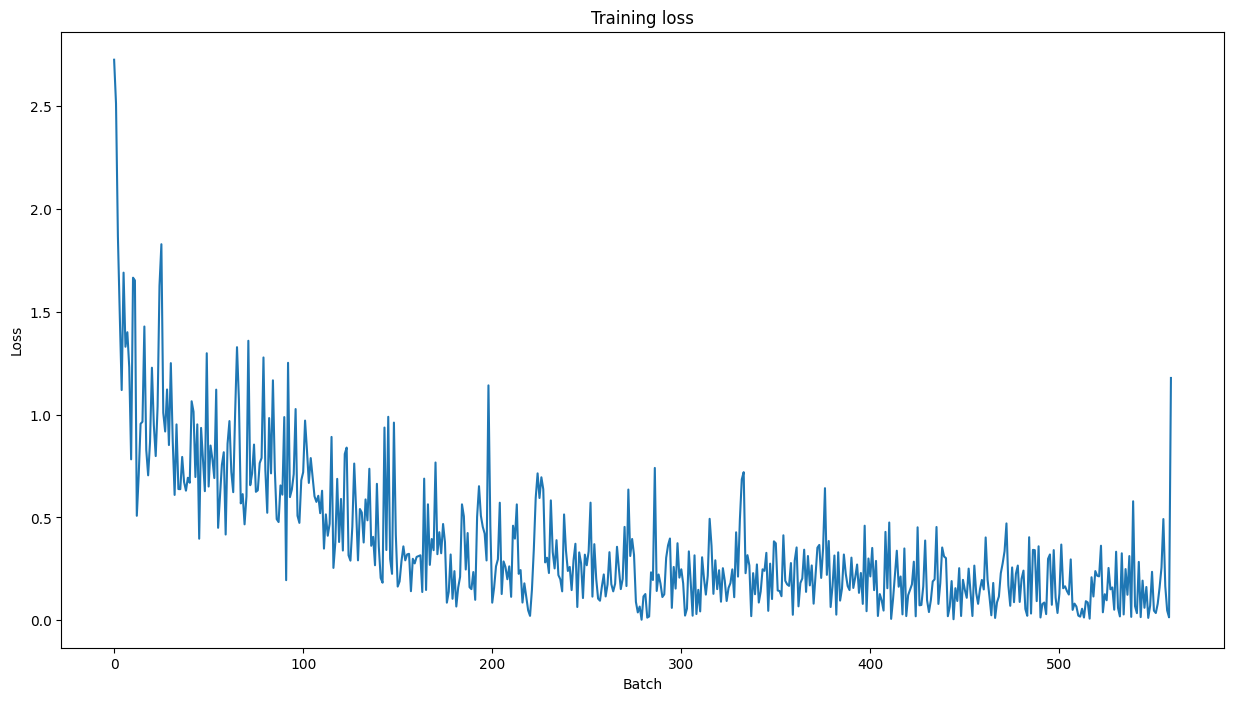

In [44]:
# BERT fine-tuning parameters
FULL_FINETUNING = True
if FULL_FINETUNING:
    param_optimizer = list(model.named_parameters())
    no_decay = ['bias', 'gamma', 'beta']
    optimizer_grouped_parameters = [
      {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
      'weight_decay_rate': 0.01},
      {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
      'weight_decay_rate': 0.0}
  ]
else:
    param_optimizer = list(model.classifier.named_parameters())
    optimizer_grouped_parameters = [{"params": [p for n, p in param_optimizer]}]

optimizer = BertAdam(optimizer_grouped_parameters, lr=3e-5)


# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

# Store our loss and accuracy for plotting
train_loss_set = []
# Number of training epochs
epochs = 4

# BERT training loop
for _ in trange(epochs, desc="Epoch"):

  ###### TRAINING ######

    # Set our model to training mode
    model.train()
    # Tracking variables
    tr_loss = 0
    nb_tr_examples, nb_tr_steps = 0, 0
    # Train the data for one epoch
    for step, batch in enumerate(train_dataloader):
        # Add batch to GPU
        batch = tuple(t.to(device) for t in batch)
        # Unpack the inputs from our dataloader
        b_input_ids, b_input_mask, b_labels = batch
        # Clear out the gradients (by default they accumulate)
        optimizer.zero_grad()
        # Forward pass
        loss = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        train_loss_set.append(loss.item())
        # Backward pass
        loss.backward()
        # Update parameters and take a step using the computed gradient
        optimizer.step()
        # Update tracking variables
        tr_loss += loss.item()
        nb_tr_examples += b_input_ids.size(0)
        nb_tr_steps += 1
    print("Train loss: {}".format(tr_loss/nb_tr_steps))

  ###### VALIDATION ######

  # Put model in evaluation mode
    model.eval()
    # Tracking variables
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0
    # Evaluate data for one epoch
    for batch in validation_dataloader:
        # Add batch to GPU
        batch = tuple(t.to(device) for t in batch)
        # Unpack the inputs from our dataloader
        b_input_ids, b_input_mask, b_labels = batch
        # Telling the model not to compute or store gradients, saving memory and speeding up validation
        with torch.no_grad():
          # Forward pass, calculate logit predictions
            logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        tmp_eval_accuracy = flat_accuracy(logits, label_ids)
        eval_accuracy += tmp_eval_accuracy
        nb_eval_steps += 1
    print("Validation Accuracy: {}".format(eval_accuracy/nb_eval_steps))

# plot training performance
plt.figure(figsize=(15,8))
plt.title("Training loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(train_loss_set)
plt.show()

# 3

In [45]:
import warnings
warnings.filterwarnings("ignore")

# install
!pip install pytorch-pretrained-bert pytorch-nlp

try :
    from google.colab import files
    %tensorflow_version 1.x

except ModuleNotFoundError :
    print("Not Using Colab")

DATA_DIR="."
import os
import numpy as np
import pickle
import tensorflow as tf

# BERT imports
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from pytorch_pretrained_bert import BertTokenizer, BertConfig
from pytorch_pretrained_bert import BertAdam, BertForSequenceClassification
from tqdm import tqdm, trange
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# specify GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    torch.cuda.get_device_name(0)

ValueError: Tensorflow 1 is unsupported in Colab.

Your notebook should be updated to use Tensorflow 2.
See the guide at https://www.tensorflow.org/guide/migrate#migrate-from-tensorflow-1x-to-tensorflow-2.

In [59]:
# importing the dataset
try :
    from google.colab import files
#   upload 'atis.test.pkl' and 'atis.train.pkl' here
    uploaded = files.upload()
#   upload 'atis.train.w-intent.iob' here
    next_uploaded = files.upload()

except ModuleNotFoundError :
    print("Not using Colab")

Saving atis.train.pkl to atis.train.pkl


In [56]:
print("Loading the training Data")
try :
    from google.colab import files
    sents,labels,intents = get_data2('atis.train.w-intent.iob')

except ModuleNotFoundError :
    sents,labels,intents = get_data2('Data/data2/atis.train.w-intent.iob')

train_sentences = [" ".join(i) for i in sents]

train_texts = train_sentences
train_labels= intents.tolist()

vals = []

for i in range(len(train_labels)):
    if "#" in train_labels[i]:
        vals.append(i)

for i in vals[::-1]:
    train_labels.pop(i)
    train_texts.pop(i)

print ("Number of training sentences :",len(train_texts))
print ("Number of unique intents :",len(set(train_labels)))

for i in zip(train_texts[:5], train_labels[:5]):
    print(i)

Loading the training Data
Number of training sentences : 4952
Number of unique intents : 17
('i want to fly from boston at 838 am and arrive in denver at 1110 in the morning', 'atis_flight')
('what flights are available from pittsburgh to baltimore on thursday morning', 'atis_flight')
('what is the arrival time in san francisco for the 755 am flight leaving washington', 'atis_flight_time')
('cheapest airfare from tacoma to orlando', 'atis_airfare')
('round trip fares from pittsburgh to philadelphia under 1000 dollars', 'atis_airfare')


In [57]:
# load Pickle file
def load_ds(fname, verbose=True):
    with open(fname, 'rb') as stream:
        ds,dicts = pickle.load(stream)
    if verbose:
        print('Done  loading: ', fname)
        print('      samples: {:4d}'.format(len(ds['query'])))
        print('   vocab_size: {:4d}'.format(len(dicts['token_ids'])))
        print('   slot count: {:4d}'.format(len(dicts['slot_ids'])))
        print(' intent count: {:4d}'.format(len(dicts['intent_ids'])))
    return ds,dicts

# convert Pickle file to arrays
def load_atis(filename, add_start_end_token=False, verbose=True):
    train_ds, dicts = load_ds(os.path.join(DATA_DIR,filename), verbose)
    t2i, s2i, in2i = map(dicts.get, ['token_ids', 'slot_ids','intent_ids'])
    i2t, i2s, i2in = map(lambda d: {d[k]:k for k in d.keys()}, [t2i,s2i,in2i])
    query, slots, intent =  map(train_ds.get, ['query', 'slot_labels', 'intent_labels'])

    if add_start_end_token:
        i2s[178] = 'BOS'
        i2s[179] = 'EOS'
        s2i['BOS'] = 178
        s2i['EOS'] = 179

    input_tensor = []
    target_tensor = []
    query_data = []
    intent_data = []
    slot_data = []
    to_show = np.random.randint(0, len(query)-1, 5)
    for i in range(len(query)):
        input_tensor.append(query[i])
        slot_text = []
        slot_vector = []
        for j in range(len(query[i])):
            slot_text.append(i2s[slots[i][j]])
            slot_vector.append(slots[i][j])
        if add_start_end_token:
            slot_text[0] = 'BOS'
            slot_vector[0] = 178
            slot_text[-1] = 'EOS'
            slot_vector[-1]= 179
        target_tensor.append(slot_vector)
        q = ' '.join(map(i2t.get, query[i]))
        query_data.append(q.replace('BOS', '').replace('EOS',''))
        intent_data.append(i2in[intent[i][0]])
        slot = ' '.join(slot_text)
        slot_data.append(slot[1:-1])
        if i in to_show and verbose:
            print('Query text:', q)
            print('Query vector: ', query[i])
            print('Intent label: ', i2in[intent[i][0]])
            print('Slot text: ', slot)
            print('Slot vector: ', slot_vector)
            print('*'*74)

    query_data = np.array(query_data)
    intent_data = np.array(intent_data)
    slot_data = np.array(slot_data)
    intent_data_label = np.array(intent).flatten()

    return t2i, s2i, in2i, i2t, i2s, i2in, input_tensor, target_tensor, query_data, intent_data, intent_data_label, slot_data

In [60]:
# load ATIS training dataset
try :
    from google.colab import files
    t2i_train, s2i_train, in2i_train, i2t_train, i2s_train, i2in_train, \
    input_tensor_train, target_tensor_train, \
    query_data_train, intent_data_train, intent_data_label_train, slot_data_train = load_atis('atis.train.pkl')

except ModuleNotFoundError :
    t2i_train, s2i_train, in2i_train, i2t_train, i2s_train, i2in_train, \
    input_tensor_train, target_tensor_train, \
    query_data_train, intent_data_train, intent_data_label_train, slot_data_train = load_atis('Data/data/atis.train.pkl')

# load ATIS testing dataset
try :
    from google.colab import files
    t2i_test, s2i_test, in2i_test, i2t_test, i2s_test, i2in_test, \
    input_tensor_test, target_tensor_test, \
    query_data_test, intent_data_test, intent_data_label_test, slot_data_test = load_atis('atis.test.pkl')

except ModuleNotFoundError :
    t2i_test, s2i_test, in2i_test, i2t_test, i2s_test, i2in_test, \
    input_tensor_test, target_tensor_test, \
    query_data_test, intent_data_test, intent_data_label_test, slot_data_test = load_atis('Data/data/atis.test.pkl')

Done  loading:  ./atis.train.pkl
      samples: 4978
   vocab_size:  943
   slot count:  129
 intent count:   26
Query text: BOS list the flights on friday afternoon from philadelphia to oakland EOS
Query vector:  [178 549 827 429 654 441 191 444 678 851 644 179]
Intent label:  flight
Slot text:  O O O O O B-depart_date.day_name B-depart_time.period_of_day O B-fromloc.city_name O B-toloc.city_name O
Slot vector:  [np.int64(128), np.int64(128), np.int64(128), np.int64(128), np.int64(128), np.int64(26), np.int64(33), np.int64(128), np.int64(48), np.int64(128), np.int64(78), np.int64(128)]
**************************************************************************
Query text: BOS find a flight from toronto to san diego with a layover in san francisco on air canada EOS
Query vector:  [178 423 180 428 444 856 851 739 364 925 180 535 482 739 440 654 195 283
 179]
Intent label:  flight
Slot text:  O O O O O B-fromloc.city_name O B-toloc.city_name I-toloc.city_name O O O O B-stoploc.city_name I

In [61]:
query_data_train

array([' i want to fly from boston at 838 am and arrive in denver at 1110 in the morning ',
       ' what flights are available from pittsburgh to baltimore on thursday morning ',
       ' what is the arrival time in san francisco for the 755 am flight leaving washington ',
       ..., ' which airlines fly into and out of denver ',
       ' does continental fly from boston to san francisco with a stop in denver ',
       ' is there a delta flight from denver to san francisco '],
      dtype='<U261')

In [62]:
#function to find the length of a tensor
def max_length(tensor):
    return max(len(t) for t in tensor)

# Helper function to pad the query tensor and slot (target) tensor to the same length.
# Also creates a tensor for teacher forcing.
def create_tensors(input_tensor, target_tensor, nb_sample=9999999, max_len=0):
    len_input, len_target  = max_length(input_tensor), max_length(target_tensor)
    len_input = max(len_input,max_len)
    len_target = max(len_target,max_len)


    # Padding the input and output tensor to the maximum length
    input_data = tf.keras.preprocessing.sequence.pad_sequences(input_tensor,
                                                                 maxlen=len_input,
                                                                 padding='post')

    teacher_data = tf.keras.preprocessing.sequence.pad_sequences(target_tensor,
                                                                  maxlen=len_target ,
                                                                  padding='post')

    target_data = [[teacher_data[n][i+1] for i in range(len(teacher_data[n])-1)] for n in range(len(teacher_data))]
    target_data = tf.keras.preprocessing.sequence.pad_sequences(target_data, maxlen=len_target, padding="post")
    target_data = target_data.reshape((target_data.shape[0], target_data.shape[1], 1))

    nb = len(input_data)
    p = np.random.permutation(nb)
    input_data = input_data[p]
    teacher_data = teacher_data[p]
    target_data = target_data[p]

    return input_data[:min(nb_sample, nb)], teacher_data[:min(nb_sample, nb)], target_data[:min(nb_sample, nb)], len_input, len_target

input_data_train, teacher_data_train, target_data_train, \
                  len_input_train, len_target_train  = create_tensors(input_tensor_train, target_tensor_train)
input_data_test, teacher_data_test, target_data_test, \
                 len_input_test, len_target_test  = create_tensors(input_tensor_test, target_tensor_test, max_len=len_input_train)

In [63]:
sentences = ["[CLS] " + query + " [SEP]" for query in query_data_train]
print(sentences[0])

# Tokenize with BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)
tokenized_texts = [tokenizer.tokenize(sent) for sent in sentences]
print ("Tokenize the first sentence:")
print (tokenized_texts[0])

[CLS]  i want to fly from boston at 838 am and arrive in denver at 1110 in the morning  [SEP]
Tokenize the first sentence:
['[', 'cl', '##s', ']', 'i', 'want', 'to', 'fly', 'from', 'boston', 'at', '83', '##8', 'am', 'and', 'arrive', 'in', 'denver', 'at', '111', '##0', 'in', 'the', 'morning', '[', 'sep', ']']


In [64]:
# Set the maximum sequence length.
MAX_LEN = 128
# Pad our input tokens
input_ids = pad_sequences([tokenizer.convert_tokens_to_ids(txt) for txt in tokenized_texts],
                          maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")
# Use the BERT tokenizer to convert the tokens to their index numbers in the BERT vocabulary
input_ids = [tokenizer.convert_tokens_to_ids(x) for x in tokenized_texts]
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype="long", truncating="post", padding="post")

In [65]:
# Create attention masks
attention_masks = []
# Create a mask of 1s for each token followed by 0s for padding
for seq in input_ids:
    seq_mask = [float(i>0) for i in seq]
    attention_masks.append(seq_mask)

In [66]:
#Reducing this into a binary classifcation problem
intent_data_label_train[intent_data_label_train==14] = -1
intent_data_label_train[intent_data_label_train!=-1] = 0
intent_data_label_train[intent_data_label_train==-1] = 1

In [67]:
# Use train_test_split to split our data into train and validation sets for training
train_inputs, validation_inputs, train_labels, validation_labels = train_test_split(input_ids, intent_data_label_train,
                                                            random_state=2018, test_size=0.1)
train_masks, validation_masks, _, _ = train_test_split(attention_masks, input_ids,
                                             random_state=2018, test_size=0.1)

# Convert all of our data into torch tensors, the required datatype for our model
train_inputs = torch.tensor(train_inputs)
validation_inputs = torch.tensor(validation_inputs)
train_labels = torch.tensor(train_labels)
validation_labels = torch.tensor(validation_labels)
train_masks = torch.tensor(train_masks)
validation_masks = torch.tensor(validation_masks)

# Select a batch size for training.
batch_size = 32

# Create an iterator of our data with torch DataLoader
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
validation_data = TensorDataset(validation_inputs, validation_masks, validation_labels)
validation_sampler = SequentialSampler(validation_data)
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)

In [68]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

if torch.cuda.is_available():
    model.cuda()
else :
    model

Epoch:   0%|          | 0/4 [00:00<?, ?it/s]

Train loss: 0.5851051207099642


Epoch:  25%|██▌       | 1/4 [01:51<05:33, 111.21s/it]

Validation Accuracy: 0.7463107638888888
Train loss: 0.35009135827422144


Epoch:  50%|█████     | 2/4 [03:43<03:43, 111.67s/it]

Validation Accuracy: 0.943359375
Train loss: 0.1890333683629121


Epoch:  75%|███████▌  | 3/4 [05:35<01:52, 112.02s/it]

Validation Accuracy: 0.94921875
Train loss: 0.15096240466726676


Epoch: 100%|██████████| 4/4 [07:28<00:00, 112.00s/it]

Validation Accuracy: 0.9476996527777778


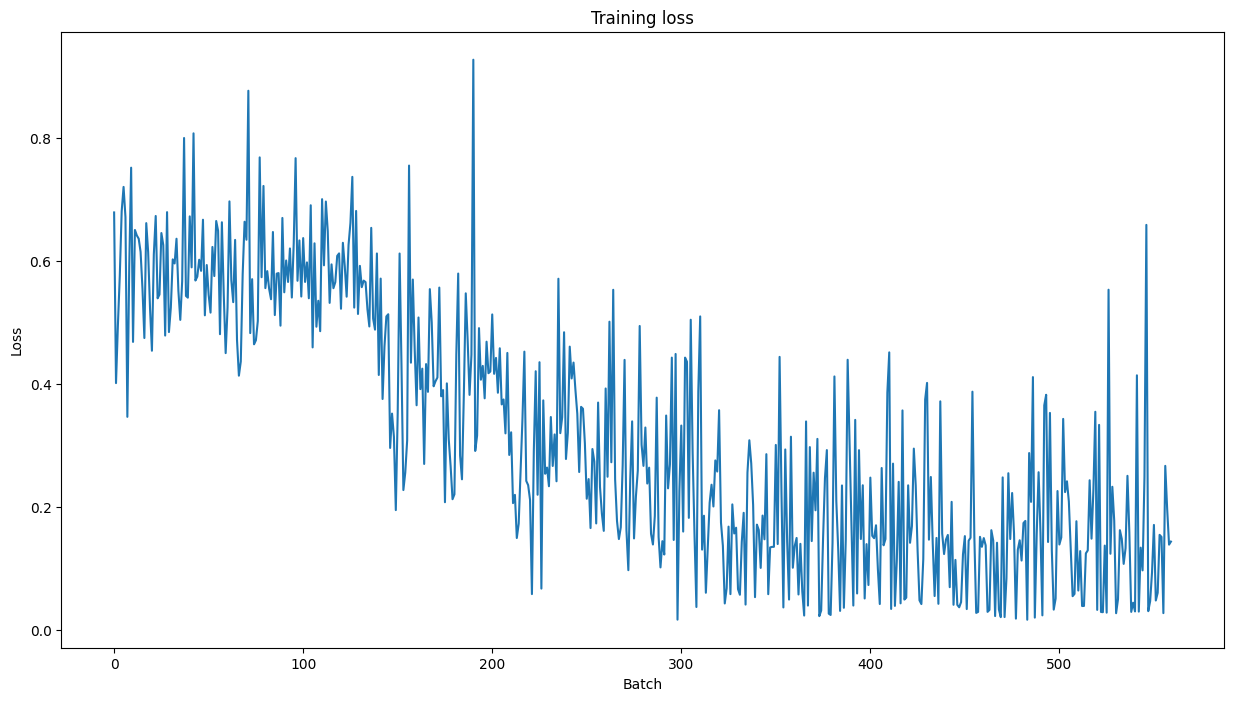

In [69]:
# BERT fine-tuning parameters
param_optimizer = list(model.named_parameters())
no_decay = ['bias', 'gamma', 'beta']
optimizer_grouped_parameters = [
    {'params': [p for n, p in param_optimizer if not any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.01},
    {'params': [p for n, p in param_optimizer if any(nd in n for nd in no_decay)],
     'weight_decay_rate': 0.0}
]

optimizer = BertAdam(optimizer_grouped_parameters,
                     lr=2e-5,
                     warmup=.1)

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

# Store our loss and accuracy for plotting
train_loss_set = []
# Number of training epochs
epochs = 4

# BERT training loop
for _ in trange(epochs, desc="Epoch"):

  ## TRAINING

  # Set our model to training mode
    model.train()
    # Tracking variables
    tr_loss = 0
    nb_tr_examples, nb_tr_steps = 0, 0
  # Train the data for one epoch
    for step, batch in enumerate(train_dataloader):
    # Add batch to GPU
        batch = tuple(t.to(device) for t in batch)
        # Unpack the inputs from our dataloader
        b_input_ids, b_input_mask, b_labels = batch
        # Clear out the gradients (by default they accumulate)
        optimizer.zero_grad()
        # Forward pass
        loss = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        train_loss_set.append(loss.item())
        # Backward pass
        loss.backward()
        # Update parameters and take a step using the computed gradient
        optimizer.step()
        # Update tracking variables
        tr_loss += loss.item()
        nb_tr_examples += b_input_ids.size(0)
        nb_tr_steps += 1
    print("Train loss: {}".format(tr_loss/nb_tr_steps))

  ## VALIDATION

    # Put model in evaluation mode
    model.eval()
    # Tracking variables
    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0
    # Evaluate data for one epoch
    for batch in validation_dataloader:
    # Add batch to GPU
        batch = tuple(t.to(device) for t in batch)
        # Unpack the inputs from our dataloader
        b_input_ids, b_input_mask, b_labels = batch
        # Telling the model not to compute or store gradients, saving memory and speeding up validation
        with torch.no_grad():
          # Forward pass, calculate logit predictions
            logits = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
        # Move logits and labels to CPU
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()
        tmp_eval_accuracy = flat_accuracy(logits, label_ids)
        eval_accuracy += tmp_eval_accuracy
        nb_eval_steps += 1
    print("Validation Accuracy: {}".format(eval_accuracy/nb_eval_steps))

# plot training performance
plt.figure(figsize=(15,8))
plt.title("Training loss")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.plot(train_loss_set)
plt.show()

# 4

In [74]:
import os
import json
import string
!pip install wget
import wget
from zipfile import ZipFile

import numpy as np
import nltk
nltk.download('averaged_perceptron_tagger')
from nltk.tag import pos_tag

!pip install sklearn_crfsuite
from sklearn_crfsuite import CRF, metrics
from sklearn.metrics import make_scorer,confusion_matrix
from sklearn.metrics import f1_score,classification_report
from sklearn.pipeline import Pipeline

from pprint import pprint

!pip install keras-preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [76]:
try:
    from google.colab import files
#   upload "train_PlayMusic_full.json" and "validate_PlayMusic.json" here
    uploaded = files.upload()
    train_loc = "train_PlayMusic_full.json"
    test_loc = "validate_PlayMusic.json"

except ModuleNotFoundError:
    train_loc = "Data/snips/train_PlayMusic_full.json"
    test_loc = "Data/snips/validate_PlayMusic.json"

train_file = json.load(open(train_loc, encoding= "iso-8859-2"))
test_file = json.load(open(test_loc, encoding= "iso-8859-2"))

Saving validate_PlayMusic.json to validate_PlayMusic.json


In [77]:
train_datafile = [i["data"] for i in train_file["PlayMusic"]]
test_datafile = [i["data"] for i in test_file["PlayMusic"]]

In [78]:
def convert_data(datalist):
    output = []
    for data in datalist:
        sent = []
        pos = []
        for phrase in data:
            words = phrase["text"].strip().split(" ")
            while "" in words:
                words.remove("")
            if "entity" in phrase.keys():
                label = phrase["entity"]
                labels = [label+"-{}".format(i+1) for i in range(len(words))]
            else:
                labels = ["O"] * len(words)
            sent.extend(words)
            pos.extend(labels)
        output.append([sent, pos])
        print(sent)
    return output

In [79]:
train_data = convert_data(train_datafile)
test_data = convert_data(test_datafile)

['I', 'need', 'to', 'hear', 'the', 'song', 'Aspro', 'Mavro', 'from', 'Bill', 'Szymczyk', 'on', 'Youtube']
['play', 'Yo', 'Ho', 'from', 'the', 'new', 'york', 'pops', 'on', 'Youtube']
['Play', 'some', 'seventies', 'music', 'by', 'Janne', 'Puurtinen', 'on', 'Youtube', '.']
['play', 'the', 'MĂşsica', 'Da', 'SĂŠrie', 'De', 'Filmes', 'O', 'Hobbit', 'album', 'by', 'Alex', 'Otaola']
['Play', 'Magic', 'Sam', 'from', 'the', 'thirties']
['Play', 'The', 'Soft', 'Parade', '.']
['Play', 'music', 'by', 'blowfly', 'from', 'the', 'seventies']
['play', 'Jeff', 'Pilson', 'on', 'Youtube']
['play', 'a', 'tune', 'by', 'Syreeta', 'Wright', 'from', 'twenties', 'from', 'the', 'top']
['Please', 'play', 'me', 'Jerry', 'Lee', 'Lewis', "'s", 'If', 'You', 'Say', 'So', 'track', '.']
['play', 'the', 'newest', 'by', 'Exuma']
['Play', 'the', 'album', 'alas', 'y', 'raĂ\xadces', 'by', 'Dave', 'Pybus', '.']
['play', 'music', 'by', 'Helen', 'Ward']
['Play', 'some', 'sixties', 'music.']
['Plan', 'an', 'album', 'by', 'Roni',

In [80]:
try :
    from google.colab import files
    !wget -P glove.6B http://nlp.stanford.edu/data/glove.6B.zip
    !unzip glove.6B/glove.6B.zip -d glove.6B
    BASE_DIR='.'
except ModuleNotFoundError :
    if not os.path.exists(os.getcwd()+'\\Data\\glove.6B'):
            os.mkdir(os.getcwd()+'\\Data\\glove.6B')

            url='http://nlp.stanford.edu/data/glove.6B.zip'
            path=os.getcwd()+'\Data'
            wget.download(url,path)

            temp=path+'\glove.6B.zip'
            file = ZipFile(temp)
            file.extractall(path+'\glove.6B')
            file.close()

    BASE_DIR = 'Data'

GLOVE_DIR = os.path.join(BASE_DIR, 'glove.6B')
MAX_SEQUENCE_LENGTH = 300
MAX_NUM_WORDS = 20000
EMBEDDING_DIM = 100
VALIDATION_SPLIT = 0.3

--2025-10-07 03:02:40--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-10-07 03:02:40--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-10-07 03:02:40--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B/glove.6B.z

In [ ]:
print('Preparing embedding matrix.')

# first, build index mapping words in the embeddings set
# to their embedding vector

embeddings_index = {}
with open(os.path.join(GLOVE_DIR, 'glove.6B.100d.txt'), encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print('Found %s word vectors in Glove embeddings.' % len(embeddings_index))

def get_embeddings(word):
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is None:
        # words not found in embedding index will be all-zeros.
        embedding_vector = np.zeros(shape=(EMBEDDING_DIM, ))
    return embedding_vector

In [ ]:
train_texts = [" ".join(i[0]) for i in train_data]
test_texts = [" ".join(i[0]) for i in test_data]

train_texts[0]